### Importación de datos



In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)


tienda1['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

# Unir en un solo DataFrame
df = pd.concat([tienda1, tienda2, tienda3, tienda4], ignore_index=True)

df['Ingresos'] = df['Precio'] + df['Costo de envío']


#Encabezados
df.head()






,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda,Ingresos
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1,171200.0
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359,Tienda 1,200700.0
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444,Tienda 1,225500.0
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250,Tienda 1,798500.0
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 1,355400.0


#1. Análisis de facturación



In [20]:
facturacion = df.groupby('Tienda')['Ingresos'].sum().sort_values(ascending=False)

In [23]:
# Mostrar los ingresos con separador de miles
print("Facturación total por tienda:")
for tienda, ingreso in facturacion.items():
    print(f"{tienda}: ${ingreso:,.2f}")


Facturación total por tienda:
Tienda 1: $1,212,258,300.00
Tienda 2: $1,175,828,600.00
Tienda 3: $1,156,536,200.00
Tienda 4: $1,093,693,100.00


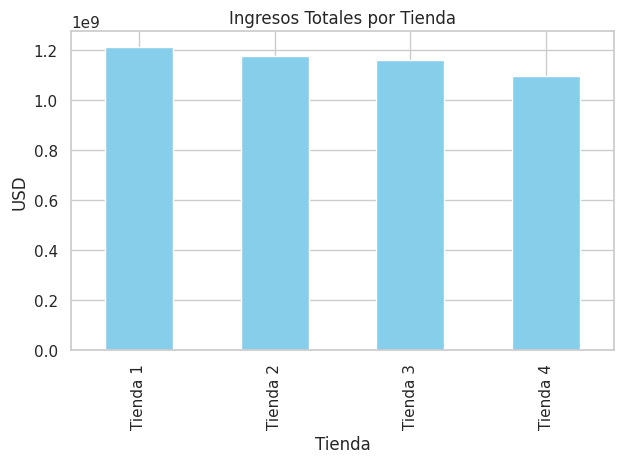

In [24]:
# Mostrar gráfico
facturacion.plot(kind='bar', title='Ingresos Totales por Tienda', ylabel='USD', xlabel='Tienda', color='skyblue')
plt.tight_layout()
plt.show()

# 2. Ventas por categoría

In [33]:
ventas_categoria = df['Categoría del Producto'].value_counts().head(5)

# Convertir a DataFrame y renombrar columnas
ventas_categoria_df = ventas_categoria.reset_index()
ventas_categoria_df.columns = ['Categoría', 'Cantidad']

# Mostrar tabla bonita
print("Top 5 categorías más vendidas:")
print(ventas_categoria_df)

Top 5 categorías más vendidas:
              Categoría  Cantidad
0               Muebles      1886
1          Electrónicos      1772
2              Juguetes      1290
3     Electrodomésticos      1149
4  Deportes y diversión      1113


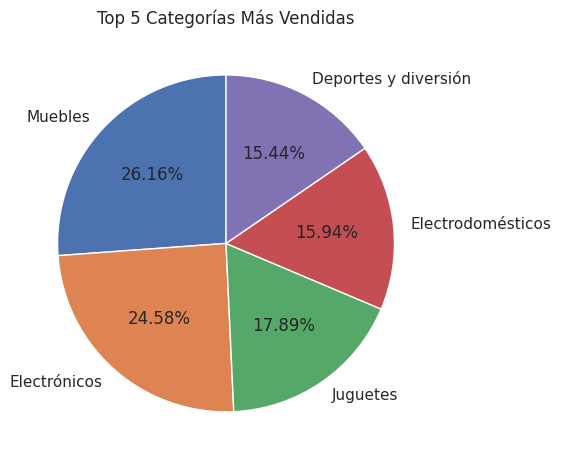

In [34]:
# Mostrar gráfico de pastel (pie chart)
ventas_categoria.plot(kind='pie', autopct='%1.2f%%', startangle=90, title='Top 5 Categorías Más Vendidas')
plt.ylabel('')  # Quitar etiqueta del eje Y
plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


In [66]:
calificaciones = df.groupby('Tienda')['Calificación'].mean().sort_values(ascending=False)


In [67]:
# Mostrar valores en consola
print("Calificación promedio por tienda:")
for tienda, calificacion in calificaciones.items():
    print(f"{tienda}: {calificacion:.3f}")

Calificación promedio por tienda:
Tienda 3: 4.048
Tienda 2: 4.037
Tienda 4: 3.996
Tienda 1: 3.977


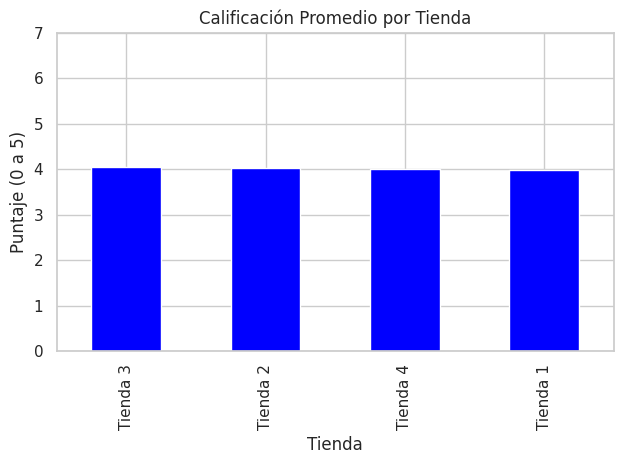

In [43]:
# Mostrar gráfico de barras
calificaciones.plot(
    kind='bar',
    title='Calificación Promedio por Tienda',
    ylabel='Puntaje (0 a 5)',
    xlabel='Tienda',
    color='blue'
)
plt.ylim(0, 7)  # Porque la calificación va del 0 al 5
plt.tight_layout()
plt.show()

# 4. Productos más y menos vendidos

*   Elemento de la lista
*   Elemento de la lista



In [48]:
top_productos = df['Producto'].value_counts().head(5)


# Convertir a DataFrame y renombrar columnas
top_productos_df = top_productos.reset_index()
top_productos_df.columns = ['Producto', 'Cantidad']

top_productos_df.insert(0, 'ID', range(1, len(top_productos_df) + 1))


# Mostrar tabla bonita
print("Top 5 categorías más vendidas:")
print(top_productos_df)

Top 5 categorías más vendidas:
   ID                   Producto  Cantidad
0   1              Mesa de noche       210
1   2  Carrito de control remoto       206
2   3                 Microondas       206
3   4                    Batería       203
4   5                  Cama king       201


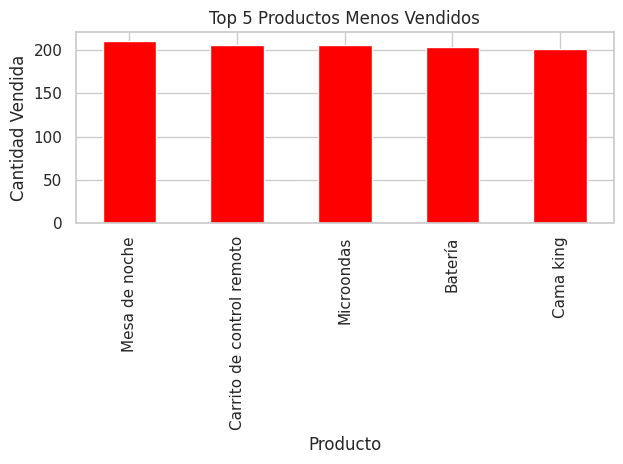

In [51]:
# Mostrar gráfico
top_productos.plot(kind='bar', title='Top 5 Productos Menos Vendidos', color='red')
plt.ylabel('Cantidad Vendida')
plt.xlabel('Producto')
plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

*   Elemento de la lista
*   Elemento de la lista



In [55]:
envio_promedio = df.groupby('Tienda')['Costo de envío'].mean().sort_values(ascending=False)

In [57]:
# Mostrar valores numéricos
print("Costo promedio de envío por tienda:")
for tienda, costo in envio_promedio.items():
    print(f"{tienda}: ${costo:.2f}")

Costo promedio de envío por tienda:
Tienda 1: $26018.61
Tienda 2: $25216.24
Tienda 3: $24805.68
Tienda 4: $23459.46


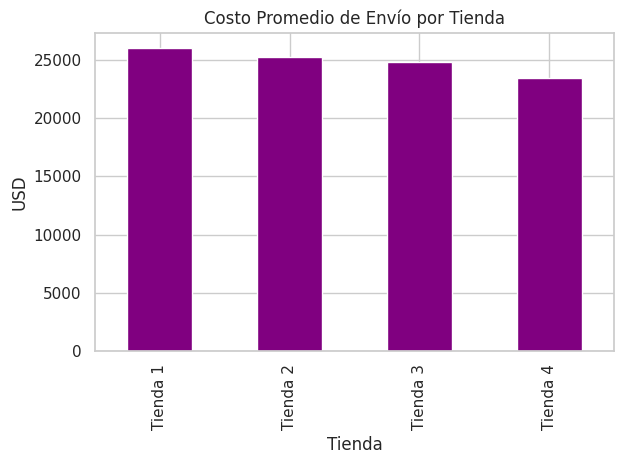

In [59]:
# Mostrar gráfico de barras
envio_promedio.plot(
    kind='bar',
    title='Costo Promedio de Envío por Tienda',
    ylabel='USD',
    xlabel='Tienda',
    color='purple'
)
plt.tight_layout()
plt.show()

In [61]:
'''
Resumen rápido de análisis:

Facturación:
Calculamos el total de ingresos de cada tienda. Esto muestra cuánto dinero generó cada una con sus ventas y envíos.

Ventas por categoría:
Identificamos las 5 categorías de productos más vendidas para entender qué tipos de productos tienen mayor demanda.

Calificación promedio:
Evaluamos la satisfacción del cliente con base en las calificaciones promedio que cada tienda recibió.

Productos más y menos vendidos:
Vimos cuáles productos fueron los más populares y cuáles tuvieron pocas ventas.

Costo promedio de envío:
Analizamos cuánto gasta cada tienda en promedio para enviar los productos a los clientes.

Conclusión:

La tienda recomendada para vender es la Tienda 4 que presenta menor facturación,
menor calificación y costos de envío relativamente altos, ya que estas señales indican
menor eficiencia y rentabilidad. Esto permitirá que Juan pueda invertir en un nuevo negocio
con recursos provenientes de la tienda menos competitiva y enfocarse en fortalecer
las tiendas que están funcionando mejor.
'''



'\nResumen rápido de análisis:\n\nFacturación:\nCalculamos el total de ingresos de cada tienda. Esto muestra cuánto dinero generó cada una con sus ventas y envíos.\n\nVentas por categoría:\nIdentificamos las 5 categorías de productos más vendidas para entender qué tipos de productos tienen mayor demanda.\n\nCalificación promedio:\nEvaluamos la satisfacción del cliente con base en las calificaciones promedio que cada tienda recibió.\n\nProductos más y menos vendidos:\nVimos cuáles productos fueron los más populares y cuáles tuvieron pocas ventas.\n\nCosto promedio de envío:\nAnalizamos cuánto gasta cada tienda en promedio para enviar los productos a los clientes.\n\nConclusión:\n\nLa tienda recomendada para vender es la que presenta menor facturación, \nmenor calificación y costos de envío relativamente altos, ya que estas señales indican\nmenor eficiencia y rentabilidad. Esto permitirá que Juan pueda invertir en un nuevo negocio\ncon recursos provenientes de la tienda menos competitiva